# Sliced Wasserstein Geometry

Sliced Wasserstein distances project high-dimensional measures onto 1D lines, where OT is cheap:
$$
\mathrm{SW}_2^2(\mu,\nu)=\int_{\theta \in \mathbb{S}^{d-1}} W_2^2(P_\theta\#\mu,\ P_\theta\#\nu)\,d\theta.
$$
Monte Carlo over random directions gives scalable approximations with strong geometric meaning.


## Environment

We import numerical and plotting libraries and define a robust output directory for figures.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("python/sliced-wasserstein") if Path("python/sliced-wasserstein").exists() else Path(".")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## Generate two 2D point clouds

We compare a circular cloud and an anisotropic shifted cloud, then estimate SW by random projections.


In [2]:
rng = np.random.default_rng(0)
n = 700

angles = rng.uniform(0, 2*np.pi, n)
r1 = 0.55 + 0.08*rng.standard_normal(n)
X = np.c_[r1*np.cos(angles), r1*np.sin(angles)]

Y = rng.standard_normal((n, 2))
Y[:, 0] = 1.2*Y[:, 0] + 0.6
Y[:, 1] = 0.45*Y[:, 1] - 0.2


## Monte Carlo SW estimator

For each unit vector $\theta$, project and sort:
$$
W_2^2(P_\theta\#\mu, P_\theta\#\nu)\approx \frac{1}{n}\sum_{i=1}^n \big(\mathrm{sort}(\theta^\top X)_i-\mathrm{sort}(\theta^\top Y)_i\big)^2.
$$


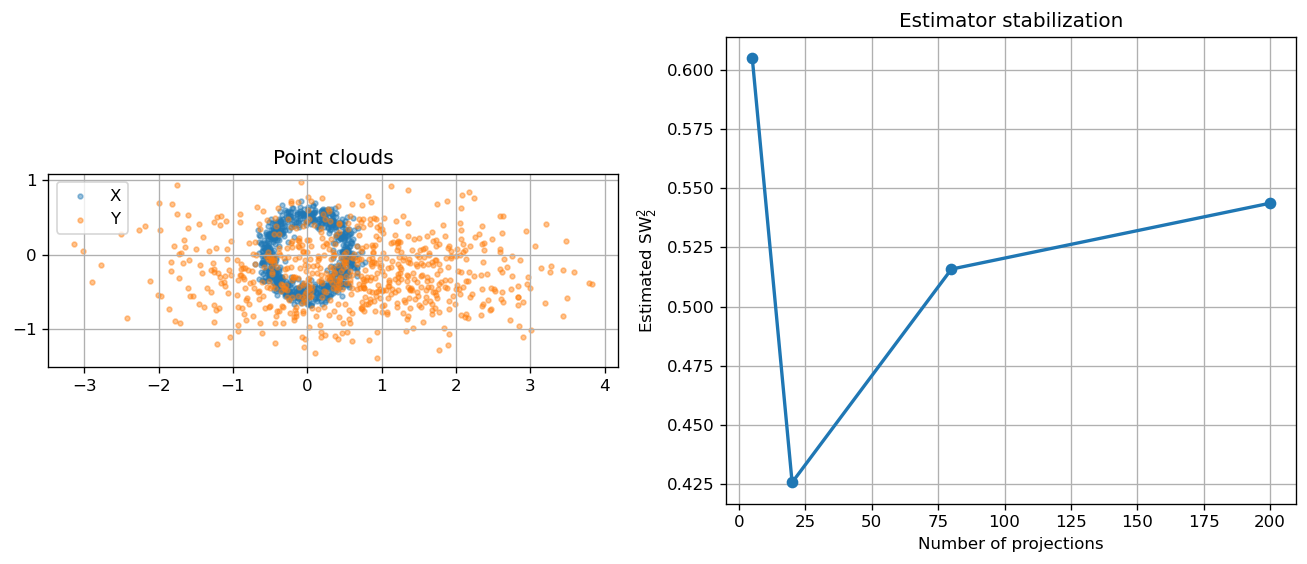

In [3]:
def sw2_estimate(X, Y, n_proj):
    vals = []
    for _ in range(n_proj):
        th = rng.standard_normal(2)
        th /= np.linalg.norm(th) + 1e-12
        px = np.sort(X @ th)
        py = np.sort(Y @ th)
        vals.append(np.mean((px - py)**2))
    vals = np.array(vals)
    return vals.mean(), vals

proj_counts = [5, 20, 80, 200]
means = []
for m in proj_counts:
    s, _ = sw2_estimate(X, Y, m)
    means.append(s)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
axes[0].scatter(X[:, 0], X[:, 1], s=8, alpha=0.45, label="X")
axes[0].scatter(Y[:, 0], Y[:, 1], s=8, alpha=0.45, label="Y")
axes[0].set_aspect("equal")
axes[0].set_title("Point clouds")
axes[0].legend()

axes[1].plot(proj_counts, means, "-o", lw=2)
axes[1].set_xlabel("Number of projections")
axes[1].set_ylabel(r"Estimated $\mathrm{SW}_2^2$")
axes[1].set_title("Estimator stabilization")

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "snippet.png", bbox_inches="tight")
plt.show()


## Bibliographical Resources

- N. Bonneel, J. Rabin, G. Peyré, H. Pfister, "Sliced and Radon Wasserstein Barycenters of Measures", JMIV, 2015.
- J. Rabin, G. Peyré, J. Delon, M. Bernot, "Wasserstein Barycenter and Its Application to Texture Mixing", SSVM, 2011.
- G. Peyré, M. Cuturi, *Computational Optimal Transport*, 2019.
